# 6. Quantitative structure models

From the points of one tree to a connected set of cylinders with volumes and
branch orders. This one starts on a synthetic tree, whose stem volume follows
from its taper, so the model can be checked against a known answer; a real
tree from the Litchfield tile follows.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import sylva
from sylva import synthetic

DATA = Path("data")          # the Litchfield tile, cut by make_litch_subset.py
plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (7, 4), "axes.grid": False})
from sylva import qsm

tree = synthetic.tree(dbh=0.35, height=14.0, seed=4)
print(tree)

PointCloud(n=79,004, attrs=['classification'])


## Leaf / wood separation

`wood_points` combines local anisotropy with a topological cue: points that many
shortest paths from the base to the crown pass through are wood. The synthetic
tree knows which points are wood, so the filter can be checked.

28,264 wood points kept; 98.4% of them lie on true wood


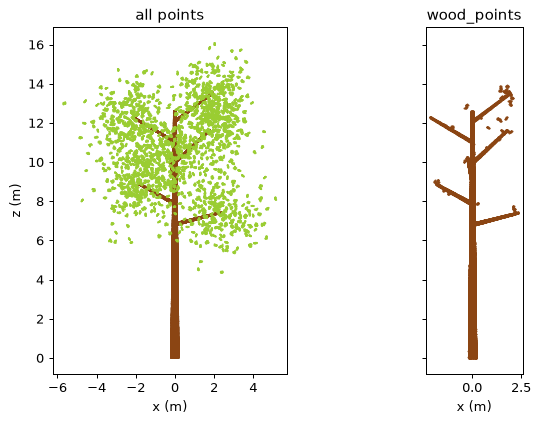

In [2]:
wood = qsm.wood_points(tree, voxel_size=0.02)
true_wood = tree[tree.attrs["classification"] == 5]
from sylva import filters
d, _ = filters.knn(true_wood.xyz, wood.xyz, 1)
print(f"{len(wood):,} wood points kept; {np.mean(d[:, 0] < 0.03):.1%} of them lie on true wood")

fig, ax = plt.subplots(1, 2, figsize=(8, 5), sharey=True)
ax[0].scatter(tree.x, tree.z, s=0.3, c=np.where(tree.attrs["classification"] == 5, "saddlebrown", "yellowgreen"))
ax[0].set(title="all points", aspect="equal", xlabel="x (m)", ylabel="z (m)")
ax[1].scatter(wood.x, wood.z, s=0.3, c="saddlebrown")
ax[1].set(title="wood_points", aspect="equal", xlabel="x (m)");

## Cylinder model

In [3]:
model = qsm.build_qsm(wood, base_xy=(0.0, 0.0))
for k, v in model.summary().items():
    print(f"{k:18s} {v:.4f}" if isinstance(v, float) else f"{k:18s} {v}")

n_cylinders        343
total_volume_m3    0.6214
stem_volume_m3     0.5797
branch_volume_m3   0.0416
total_length_m     38.2044
max_branch_order   2
dbh_m              0.3373


The stem of the synthetic tree tapers from 1.05 to 0.25 times the breast-height radius over 90 % of the height, so its volume is known:

In [4]:
r0, r1, L = 0.35 / 2 * 1.05, 0.35 / 2 * 0.25, 14.0 * 0.9
true_stem = np.pi * L / 3 * (r0**2 + r0 * r1 + r1**2)
print(f"stem volume: model {model.stem_volume:.3f} m3, truth {true_stem:.3f} m3;  DBH: model {model.dbh:.3f} m, truth 0.35 m")

stem volume: model 0.580 m3, truth 0.577 m3;  DBH: model 0.337 m, truth 0.35 m


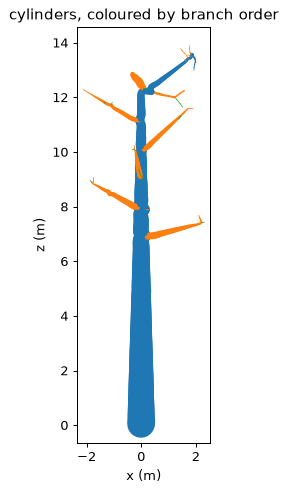

In [5]:
start, end = model.start, model.end
order = model.column("branch_order").astype(int)
fig, ax = plt.subplots(figsize=(5, 6))
for s, e, r, o in zip(start, end, model.column("radius"), order):
    ax.plot([s[0], e[0]], [s[2], e[2]], color=f"C{min(o, 9)}", lw=max(0.6, r * 120), solid_capstyle="round")
ax.set(aspect="equal", xlabel="x (m)", ylabel="z (m)", title="cylinders, coloured by branch order");

## A real tree, and why to check `measured_volume_fraction`

The same steps on the tallest tree of the Litchfield tile (notebook 5). The
tile is thinned to 5 cm and cut out of a decimated ray cloud, so the trunk and
branches are sampled far more thinly than a single-tree scan: most cylinders
end up interpolated rather than fitted. `metrics()["measured_volume_fraction"]`
says how much of the volume came from real fits, and it is the flag to filter
on before using QSM volumes.

In [6]:
from sylva import filters, ground, trees

plot = filters.voxel_downsample(sylva.read(DATA / "litch_tile.laz"), 0.02)
plot = ground.normalize_height(plot, ground.make_dtm(ground.classify_ground_pmf(plot), 0.5, bounds=(0, 0, 20, 20)))
stems = trees.detect_stems(plot)
stems, _ = trees.merge_branches(plot, stems)
labels = trees.segment_trees(plot, stems)
trees.tree_heights(plot, labels, stems)
stems, labels = trees.prune_trees(stems, labels, min_height=3.0)
tallest = max(stems, key=lambda t: t.height)

points = plot[labels == tallest.tree_id]
points = points[points.attrs["height"] > 0.3]      # leave the grass layer out of the base fit
real = qsm.build_qsm(qsm.wood_points(points, voxel_size=0.02), base_xy=(tallest.x, tallest.y))
print(f"detection: DBH {tallest.dbh:.3f} m, height {tallest.height:.1f} m")
print(f"QSM:       DBH {real.dbh:.3f} m, stem {real.stem_volume:.2f} m3, total {real.total_volume:.2f} m3, "
      f"{real.summary()['n_cylinders']} cylinders")
print(f"measured volume fraction: {real.metrics()['measured_volume_fraction']:.2f} "
      "-- on a single-tree scan this is above 0.8")

detection: DBH 0.319 m, height 20.0 m
QSM:       DBH 0.309 m, stem 0.75 m3, total 0.93 m3, 6075 cylinders
measured volume fraction: 0.40 -- on a single-tree scan this is above 0.8


Two lessons. The DBHs agree (0.31 m against 0.32 m), because breast
height is where the stem is best sampled. The volume should not be quoted:
less than half of it was fitted to points. Keeping the grass out of the base
matters too -- without the height cut the base cylinder swallows the tussocks
and the QSM DBH comes out at 0.50 m. Volumes are validated against felled
trees in [Benchmarks](../benchmarks/qsm.md), on single-tree clouds two orders
of magnitude denser than this tile.

## Export

A cylinder table, a raycloudtools-style tree file, and meshes for Blender / CloudCompare.

In [7]:
model.to_csv("tree_qsm.csv")
model.to_ply("tree_qsm.ply")        # faces coloured by branch order
model.to_obj("tree_qsm.obj")
qsm.QSM.from_csv("tree_qsm.csv").summary()["n_cylinders"]

343